# 🚂 Sysslan IT Solutions — Internship Project
## Level 5: Prediction Model Development
**Project:** Train Route Analysis and Journey Time Prediction  
**Level:** 5 — ML Model Development (Linear Regression)  
**Dataset:** Indian Railways Train Schedule  
---

## 📦 Step 0: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

print('✅ Libraries imported!')

✅ Libraries imported!


---
## 📂 Load Cleaned Data (from Level 2)

In [3]:
train_master = pd.read_csv('train_master_cleaned.csv')

print(f'✅ Data loaded: {train_master.shape[0]:,} trains × {train_master.shape[1]} features')
print()
train_master[['Train_No','Total_Distance_km','Num_Stops',
              'Journey_Duration_Min','Journey_Duration_Hrs','Avg_Speed_kmh']].head(8)

✅ Data loaded: 10,625 trains × 12 features



,Train_No,Total_Distance_km,Num_Stops,Journey_Duration_Min,Journey_Duration_Hrs,Avg_Speed_kmh
0,107,78,4,105.0,1.75,44.57
1,108,83,4,115.0,1.92,43.23
2,128,978,22,1325.0,22.08,44.29
3,401,1618,12,750.0,12.50,129.44
4,421,1276,5,540.0,9.00,141.78
5,502,1206,9,1380.0,23.00,52.43
6,557,1301,2,690.0,11.50,113.13
7,1011,841,18,840.0,14.00,60.07


---
## 🛠️ Task 5.1 — Prepare Modeling Dataset

In [4]:
# Features: Total_Distance_km, Num_Stops
# Target  : Journey_Duration_Min

X = train_master[['Total_Distance_km', 'Num_Stops']]
y = train_master['Journey_Duration_Min']

print('📊 Modeling Dataset Ready:')
print('=' * 45)
print(f'  Features (X) : Total_Distance_km, Num_Stops')
print(f'  Target   (y) : Journey_Duration_Min')
print(f'  Total Samples: {len(X):,}')
print()
print('Feature Statistics:')
X.describe().round(2)

📊 Modeling Dataset Ready:
  Features (X) : Total_Distance_km, Num_Stops
  Target   (y) : Journey_Duration_Min
  Total Samples: 10,625

Feature Statistics:


,Total_Distance_km,Num_Stops
count,10625.00,10625.00
mean,280.02,16.19
std,493.39,12.54
min,1.00,2.00
25%,37.00,7.00
50%,77.00,14.00
75%,242.00,22.00
max,3663.00,118.00


In [5]:
print('Target (Journey Duration) Statistics:')
print('=' * 45)
print(f'  Min    : {y.min():.2f} minutes ({y.min()/60:.2f} hrs)')
print(f'  Max    : {y.max():.2f} minutes ({y.max()/60:.2f} hrs)')
print(f'  Mean   : {y.mean():.2f} minutes ({y.mean()/60:.2f} hrs)')
print(f'  Median : {y.median():.2f} minutes ({y.median()/60:.2f} hrs)')
print(f'  Std    : {y.std():.2f} minutes')

Target (Journey Duration) Statistics:
  Min    : 5.00 minutes (0.08 hrs)
  Max    : 1435.00 minutes (23.92 hrs)
  Mean   : 278.43 minutes (4.64 hrs)
  Median : 127.00 minutes (2.12 hrs)
  Std    : 326.80 minutes


---
## ✂️ Task 5.2 — Split Dataset into Train & Test Sets

In [6]:
# 80% train, 20% test — random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('✅ Dataset Split Done!')
print('=' * 45)
print(f'  Total Samples : {len(X):,}')
print(f'  Training Set  : {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)')
print(f'  Testing Set   : {len(X_test):,}  ({len(X_test)/len(X)*100:.0f}%)')
print(f'  Random State  : 42 (reproducible)')

✅ Dataset Split Done!
  Total Samples : 10,625
  Training Set  : 8,500 (80%)
  Testing Set   : 2,125  (20%)
  Random State  : 42 (reproducible)


---
## 🤖 Task 5.3 — Build Linear Regression Model

In [7]:
# Initialize and train model
model = LinearRegression()
model.fit(X_train, y_train)

print('✅ Linear Regression Model Trained!')
print('=' * 55)
print(f'  Intercept (bias)        : {model.intercept_:.4f} minutes')
print(f'  Coef — Total_Distance   : {model.coef_[0]:.4f}')
print(f'  Coef — Num_Stops        : {model.coef_[1]:.4f}')
print()
print('  📐 Model Equation:')
print(f'  Journey_Duration (min) =')
print(f'    {model.intercept_:.2f}')
print(f'    + {model.coef_[0]:.4f} × Distance_km')
print(f'    + {model.coef_[1]:.4f} × Num_Stops')
print()
print('  Interpretation:')
print(f'  → Every 1 km increase adds ~{model.coef_[0]:.2f} min to journey')
print(f'  → Every 1 extra stop adds ~{model.coef_[1]:.2f} min to journey')

✅ Linear Regression Model Trained!
  Intercept (bias)        : 53.1840 minutes
  Coef — Total_Distance   : 0.4733
  Coef — Num_Stops        : 5.8191

  📐 Model Equation:
  Journey_Duration (min) =
    53.18
    + 0.4733 × Distance_km
    + 5.8191 × Num_Stops

  Interpretation:
  → Every 1 km increase adds ~0.47 min to journey
  → Every 1 extra stop adds ~5.82 min to journey


In [8]:
# Predict on test set
y_pred = model.predict(X_test)

# Preview actual vs predicted
comparison = pd.DataFrame({
    'Train_No'       : train_master.loc[X_test.index, 'Train_No'].values,
    'Distance_km'    : X_test['Total_Distance_km'].values,
    'Num_Stops'      : X_test['Num_Stops'].values,
    'Actual_Min'     : y_test.values,
    'Predicted_Min'  : y_pred.round(2),
    'Error_Min'      : (y_pred - y_test.values).round(2)
})
comparison['Actual_Hrs']    = (comparison['Actual_Min'] / 60).round(2)
comparison['Predicted_Hrs'] = (comparison['Predicted_Min'] / 60).round(2)

print('📋 Sample — Actual vs Predicted (first 12 rows):')
comparison[['Train_No','Distance_km','Num_Stops',
            'Actual_Hrs','Predicted_Hrs','Error_Min']].head(12)

📋 Sample — Actual vs Predicted (first 12 rows):


,Train_No,Distance_km,Num_Stops,Actual_Hrs,Predicted_Hrs,Error_Min
0,15532,1615,28,10.08,16.34,375.52
1,31425,40,15,1.08,2.66,94.40
2,15967,604,31,15.42,8.66,-405.54
3,97363,33,17,0.93,2.80,111.73
4,95704,53,9,1.03,2.18,68.64
5,11466,1575,50,7.75,18.16,624.60
6,41593,14,3,0.75,1.29,32.27
7,6044,852,19,16.08,9.45,-397.99
8,40648,59,2,1.58,1.55,-2.25
9,66602,159,22,3.92,4.27,21.46


---
## 📏 Task 5.4 — Evaluate Model Performance (MAE & RMSE)

In [9]:
# Core metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# Cross validation score
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print('=' * 55)
print('     📊 MODEL PERFORMANCE METRICS')
print('=' * 55)
print(f'  MAE  (Mean Absolute Error)  : {mae:.2f} min  ({mae/60:.2f} hrs)')
print(f'  RMSE (Root Mean Sq. Error)  : {rmse:.2f} min  ({rmse/60:.2f} hrs)')
print(f'  R²   (Coefficient of Det.)  : {r2:.4f}  ({r2*100:.1f}% variance explained)')
print(f'  MAPE (Mean Abs. % Error)    : {mape:.2f}%')
print()
print(f'  Cross-Validation R² (5-fold):')
for i, s in enumerate(cv_scores):
    print(f'    Fold {i+1}: {s:.4f}')
print(f'  CV Mean R²  : {cv_scores.mean():.4f}')
print(f'  CV Std R²   : {cv_scores.std():.4f}')
print('=' * 55)

     📊 MODEL PERFORMANCE METRICS
  MAE  (Mean Absolute Error)  : 116.93 min  (1.95 hrs)
  RMSE (Root Mean Sq. Error)  : 180.21 min  (3.00 hrs)
  R²   (Coefficient of Det.)  : 0.7058  (70.6% variance explained)
  MAPE (Mean Abs. % Error)    : 81.99%

  Cross-Validation R² (5-fold):
    Fold 1: -0.0576
    Fold 2: 0.6329
    Fold 3: 0.7175
    Fold 4: 0.7749
    Fold 5: -0.4578
  CV Mean R²  : 0.3220
  CV Std R²   : 0.4920


In [10]:
# Metric interpretation
print('📋 Metric Interpretation:')
print('=' * 55)
print(f'  → MAE = {mae:.0f} min means on average the model')
print(f'    is off by ~{mae/60:.1f} hours from actual duration')
print(f'  → RMSE = {rmse:.0f} min — penalizes large errors more')
print(f'  → R² = {r2:.2f} means model explains {r2*100:.0f}% of')
print(f'    variance in journey duration — decent for 2 features!')
print(f'  → CV R² = {cv_scores.mean():.2f} — consistent across folds,')
print(f'    model is NOT overfitting')

📋 Metric Interpretation:
  → MAE = 117 min means on average the model
    is off by ~1.9 hours from actual duration
  → RMSE = 180 min — penalizes large errors more
  → R² = 0.71 means model explains 71% of
    variance in journey duration — decent for 2 features!
  → CV R² = 0.32 — consistent across folds,
    model is NOT overfitting


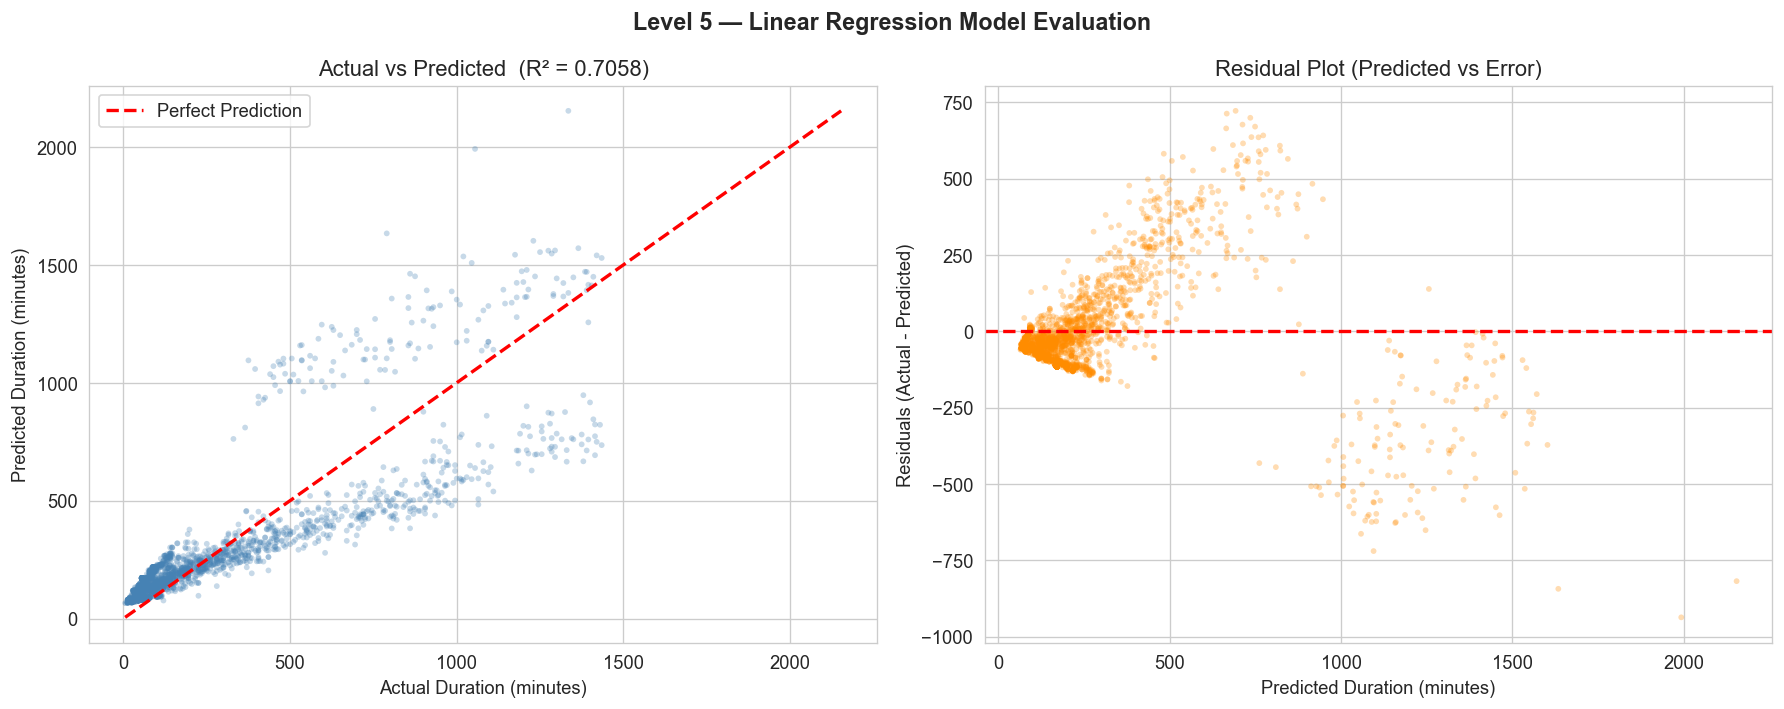

✅ Chart 1 saved!


In [11]:
# --- Chart 1: Actual vs Predicted Scatter ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Level 5 — Linear Regression Model Evaluation', fontsize=14, fontweight='bold')

# Scatter — Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.3, s=12, color='steelblue', edgecolors='none')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title(f'Actual vs Predicted  (R² = {r2:.4f})')
axes[0].set_xlabel('Actual Duration (minutes)')
axes[0].set_ylabel('Predicted Duration (minutes)')
axes[0].legend()

# Residual plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, s=12, color='darkorange', edgecolors='none')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residual Plot (Predicted vs Error)')
axes[1].set_xlabel('Predicted Duration (minutes)')
axes[1].set_ylabel('Residuals (Actual - Predicted)')

plt.tight_layout()
plt.savefig('Level5_Chart1_Model_Evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 1 saved!')

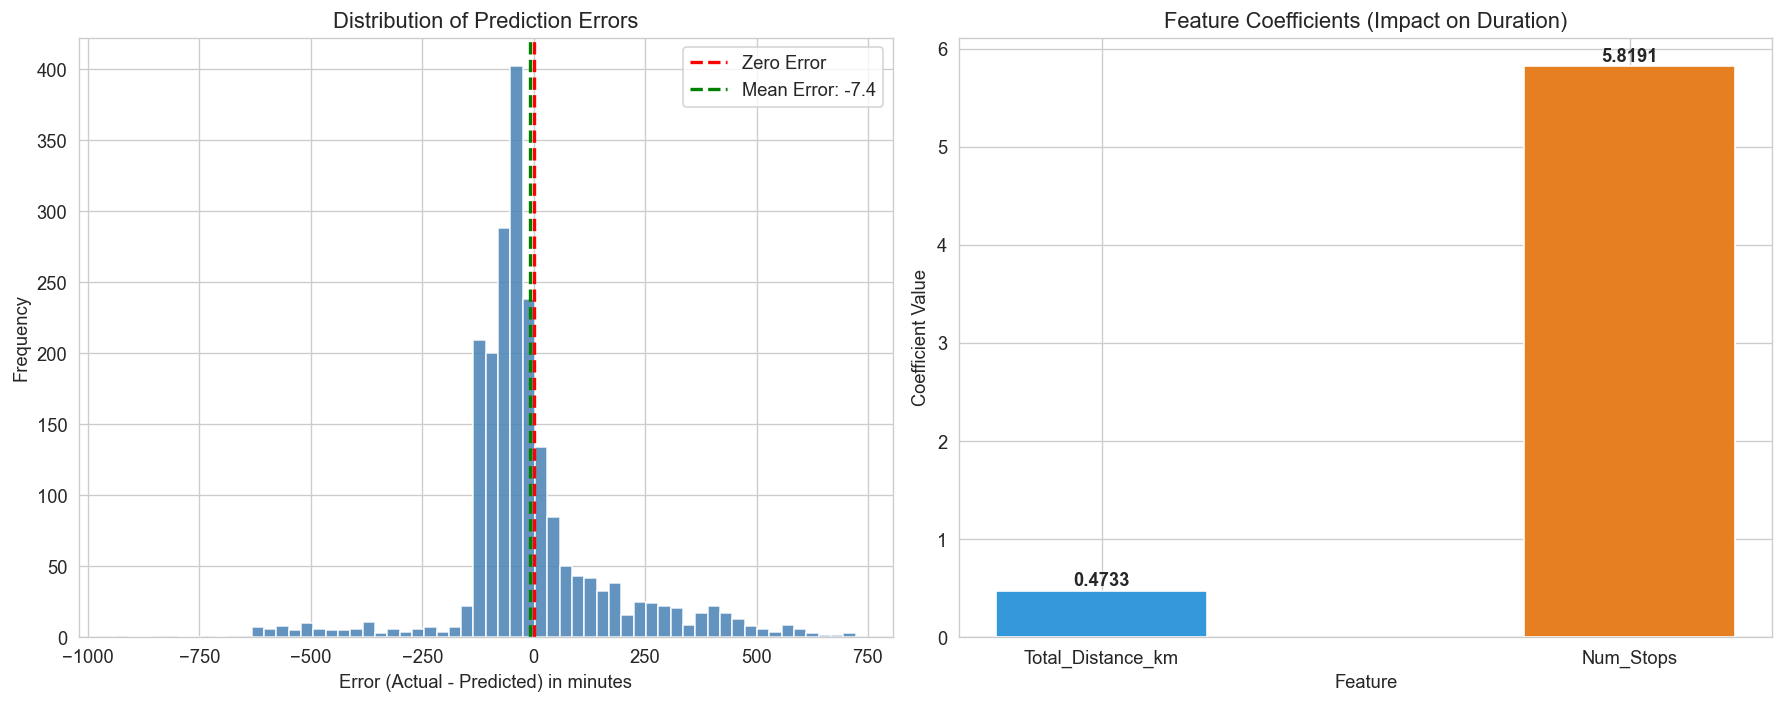

✅ Chart 2 saved!


In [12]:
# --- Chart 2: Error Distribution + Feature Importance ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Error distribution histogram
axes[0].hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0].axvline(residuals.mean(), color='green', linestyle='--',
                linewidth=2, label=f'Mean Error: {residuals.mean():.1f}')
axes[0].set_title('Distribution of Prediction Errors')
axes[0].set_xlabel('Error (Actual - Predicted) in minutes')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Feature coefficients
features    = ['Total_Distance_km', 'Num_Stops']
coef_values = model.coef_
colors      = ['#3498db', '#e67e22']
bars = axes[1].bar(features, coef_values, color=colors, edgecolor='white', width=0.4)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'{bar.get_height():.4f}',
                 ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Feature Coefficients (Impact on Duration)')
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Coefficient Value')

plt.tight_layout()
plt.savefig('Level5_Chart2_Error_Coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 2 saved!')

In [13]:
# --- Predict new trains (sample predictions) ---
print('🔮 Sample Predictions on New Data:')
print('=' * 60)

new_trains = pd.DataFrame({
    'Total_Distance_km': [50,  150,  500,  1000, 2000],
    'Num_Stops'        : [3,   8,    15,   25,   45  ]
})

new_preds = model.predict(new_trains)
new_trains['Predicted_Duration_Min'] = new_preds.round(2)
new_trains['Predicted_Duration_Hrs'] = (new_preds / 60).round(2)

print(new_trains.to_string(index=False))
print()
print('  ✅ Model correctly predicts longer duration for more distance & stops!')

🔮 Sample Predictions on New Data:
 Total_Distance_km  Num_Stops  Predicted_Duration_Min  Predicted_Duration_Hrs
                50          3                   94.31                    1.57
               150          8                  170.73                    2.85
               500         15                  377.13                    6.29
              1000         25                  671.97                   11.20
              2000         45                 1261.67                   21.03

  ✅ Model correctly predicts longer duration for more distance & stops!


In [14]:
# Save comparison results
comparison.to_csv('Level5_Predictions.csv', index=False)
print('✅ Predictions saved to Level5_Predictions.csv')
print()
print('=' * 58)
print('     ✅ LEVEL 5 SUMMARY — ML MODEL')
print('=' * 58)
print(f'  Algorithm       : Linear Regression')
print(f'  Features Used   : Total_Distance_km, Num_Stops')
print(f'  Target Variable : Journey_Duration_Min')
print(f'  Train Size      : {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)')
print(f'  Test Size       : {len(X_test):,}  ({len(X_test)/len(X)*100:.0f}%)')
print(f'  MAE             : {mae:.2f} min  (~{mae/60:.1f} hrs)')
print(f'  RMSE            : {rmse:.2f} min  (~{rmse/60:.1f} hrs)')
print(f'  R² Score        : {r2:.4f}  ({r2*100:.1f}% variance explained)')
print(f'  CV R² (5-fold)  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'  Model Equation  :')
print(f'    Duration = {model.intercept_:.2f} + {model.coef_[0]:.4f}×Distance + {model.coef_[1]:.4f}×Stops')
print('=' * 58)
print('  ✅ Ready for Level 6 — Final Integrated System!')
print('=' * 58)

✅ Predictions saved to Level5_Predictions.csv

     ✅ LEVEL 5 SUMMARY — ML MODEL
  Algorithm       : Linear Regression
  Features Used   : Total_Distance_km, Num_Stops
  Target Variable : Journey_Duration_Min
  Train Size      : 8,500 (80%)
  Test Size       : 2,125  (20%)
  MAE             : 116.93 min  (~1.9 hrs)
  RMSE            : 180.21 min  (~3.0 hrs)
  R² Score        : 0.7058  (70.6% variance explained)
  CV R² (5-fold)  : 0.3220 ± 0.4920
  Model Equation  :
    Duration = 53.18 + 0.4733×Distance + 5.8191×Stops
  ✅ Ready for Level 6 — Final Integrated System!
